In [1]:
library(DESeq2)
library(SummarizedExperiment)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomicRanges

Loading required package: GenomeInfoDb

Loa

In [2]:
setwd('/usr/users/papantonis1/aman/rnaseq_data/star_results')

In [3]:
fc <- read.table("../featurecounts_gene_counts.txt",
                  header = TRUE,
                  row.names = 1,
                  comment.char = "#",
                  check.names = FALSE)

In [4]:
count_matrix <- fc[ ,6:ncol(fc)]

In [5]:
count_matrix

,/usr/users/papantonis1/aman/rnaseq_data/star_results/S55_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S56_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S57_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S58_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S59_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S60_Aligned.sortedByCoord.out.bam
,<int>,<int>,<int>,<int>,<int>,<int>
ENSG00000290825.2,0,0,0,0,2,0
ENSG00000223972.6,0,0,0,0,0,0
ENSG00000310526.1,31,68,362,315,368,337
ENSG00000227232.6,0,0,0,0,0,0
ENSG00000278267.1,0,0,0,0,0,0
ENSG00000243485.6,0,2,0,1,0,2
ENSG00000284332.1,0,0,0,0,0,0
ENSG00000237613.3,0,0,0,0,0,0
ENSG00000308361.1,1,0,0,0,0,0


In [6]:
dim(count_matrix)

[1] 86364     6

In [7]:
#count_matrix
colnames(count_matrix)

[1] "/usr/users/papantonis1/aman/rnaseq_data/star_results/S55_Aligned.sortedByCoord.out.bam"
[2] "/usr/users/papantonis1/aman/rnaseq_data/star_results/S56_Aligned.sortedByCoord.out.bam"
[3] "/usr/users/papantonis1/aman/rnaseq_data/star_results/S57_Aligned.sortedByCoord.out.bam"
[4] "/usr/users/papantonis1/aman/rnaseq_data/star_results/S58_Aligned.sortedByCoord.out.bam"
[5] "/usr/users/papantonis1/aman/rnaseq_data/star_results/S59_Aligned.sortedByCoord.out.bam"
[6] "/usr/users/papantonis1/aman/rnaseq_data/star_results/S60_Aligned.sortedByCoord.out.bam"

In [8]:
condition <- factor(c("AuxinCPI", "AuxinCPI", "CPI", "CPI", "control", "control"),
                    levels = c("control", "CPI", "AuxinCPI"))

# control is the reference level

In [9]:
coldata <- data.frame(row.names = colnames(count_matrix),
                      condition = condition)
coldata

,condition
,<fct>
/usr/users/papantonis1/aman/rnaseq_data/star_results/S55_Aligned.sortedByCoord.out.bam,AuxinCPI
/usr/users/papantonis1/aman/rnaseq_data/star_results/S56_Aligned.sortedByCoord.out.bam,AuxinCPI
/usr/users/papantonis1/aman/rnaseq_data/star_results/S57_Aligned.sortedByCoord.out.bam,CPI
/usr/users/papantonis1/aman/rnaseq_data/star_results/S58_Aligned.sortedByCoord.out.bam,CPI
/usr/users/papantonis1/aman/rnaseq_data/star_results/S59_Aligned.sortedByCoord.out.bam,control
/usr/users/papantonis1/aman/rnaseq_data/star_results/S60_Aligned.sortedByCoord.out.bam,control


In [10]:
dds <- DESeqDataSetFromMatrix(countData = count_matrix,
                              colData = coldata,
                              design = ~ condition)

# design formula - gene expression based on the levels of the condition factor.

In [11]:
dds

class: DESeqDataSet 
dim: 86364 6 
metadata(1): version
assays(1): counts
rownames(86364): ENSG00000290825.2 ENSG00000223972.6 ...
  ENSG00000297844.1 ENSG00000309258.1
rowData names(0):
colnames(6):
  /usr/users/papantonis1/aman/rnaseq_data/star_results/S55_Aligned.sortedByCoord.out.bam
  /usr/users/papantonis1/aman/rnaseq_data/star_results/S56_Aligned.sortedByCoord.out.bam
  ...
  /usr/users/papantonis1/aman/rnaseq_data/star_results/S59_Aligned.sortedByCoord.out.bam
  /usr/users/papantonis1/aman/rnaseq_data/star_results/S60_Aligned.sortedByCoord.out.bam
colData names(1): condition

In [12]:
#colnames(dds) <- c("S55", "S56", "S57", "S58", "S59", "S60")

In [13]:
dds$condition <- relevel(dds$condition, ref = "control")
# Setting the reference level of the factor condition in the dds object to "control"

In [14]:
#counts(dds)

In [15]:
levels(dds$condition)

[1] "control"  "CPI"      "AuxinCPI"

In [16]:
dds <- DESeq(dds)
res <- results(dds, contrast = c("condition", "CPI", "control"))
res

# Fitting the negative binomial model and wald test for each gene comparing CPI vs control

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



log2 fold change (MLE): condition CPI vs control 
Wald test p-value: condition CPI vs control 
DataFrame with 86364 rows and 6 columns
                    baseMean log2FoldChange     lfcSE      stat    pvalue
                   <numeric>      <numeric> <numeric> <numeric> <numeric>
ENSG00000290825.2   0.280936      -2.422587  4.904300 -0.493972  0.621326
ENSG00000223972.6   0.000000             NA        NA        NA        NA
ENSG00000310526.1 227.447545      -0.189165  0.321656 -0.588097  0.556467
ENSG00000227232.6   0.000000             NA        NA        NA        NA
ENSG00000278267.1   0.000000             NA        NA        NA        NA
...                      ...            ...       ...       ...       ...
ENSG00000303867.1          0             NA        NA        NA        NA
ENSG00000303902.1          0             NA        NA        NA        NA
ENSG00000306528.1          0             NA        NA        NA        NA
ENSG00000297844.1          0             NA        

In [17]:
summary(res)


out of 49321 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 1059, 2.1%
LFC < 0 (down)     : 273, 0.55%
outliers [1]       : 0, 0%
low counts [2]     : 37655, 76%
(mean count < 188)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [18]:
## there are 49321 genes with non zero counts. 37k removed here

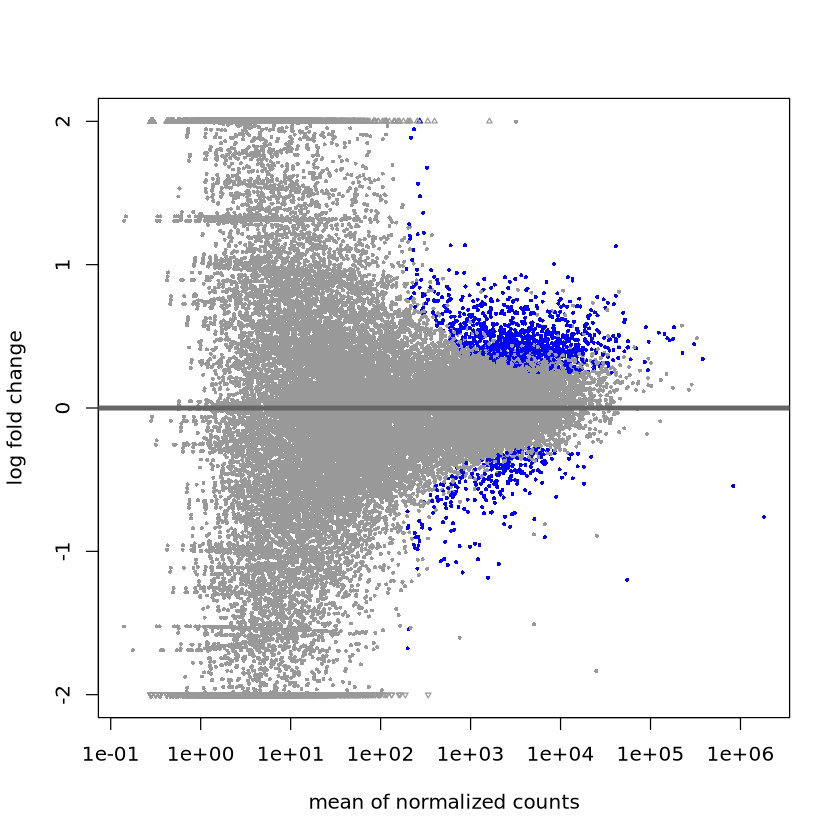

In [19]:
plotMA(res, ylim=c(-2,2))

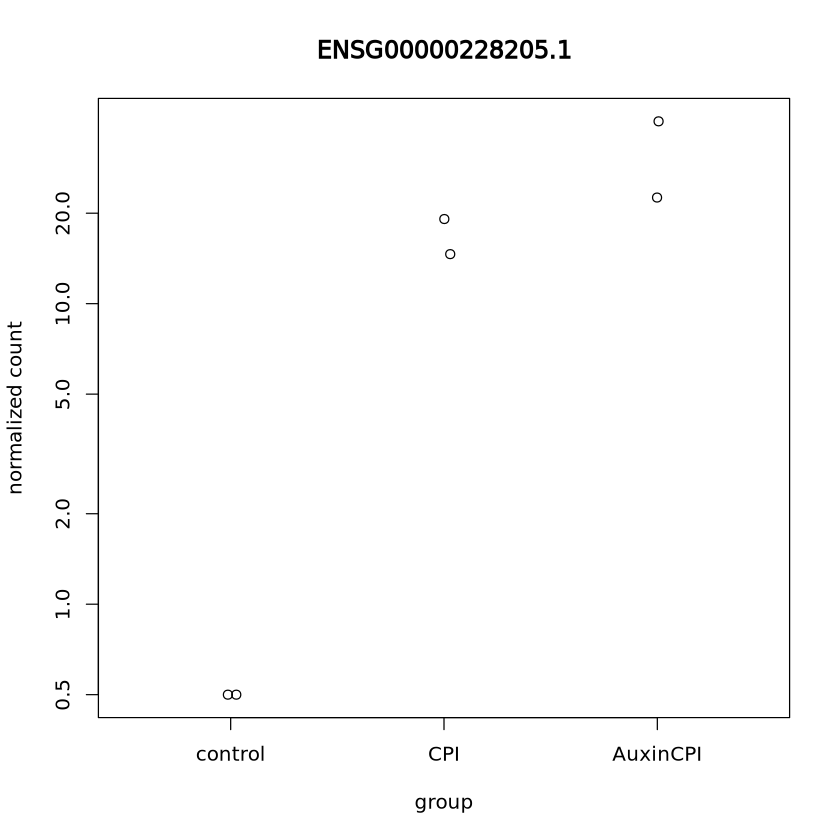

In [20]:
plotCounts(dds, gene=which.max(res$log2FoldChange), intgroup="condition")

In [21]:
#write.csv(as.data.frame(resOrdered), 
#          file="condition_treated_results.csv")

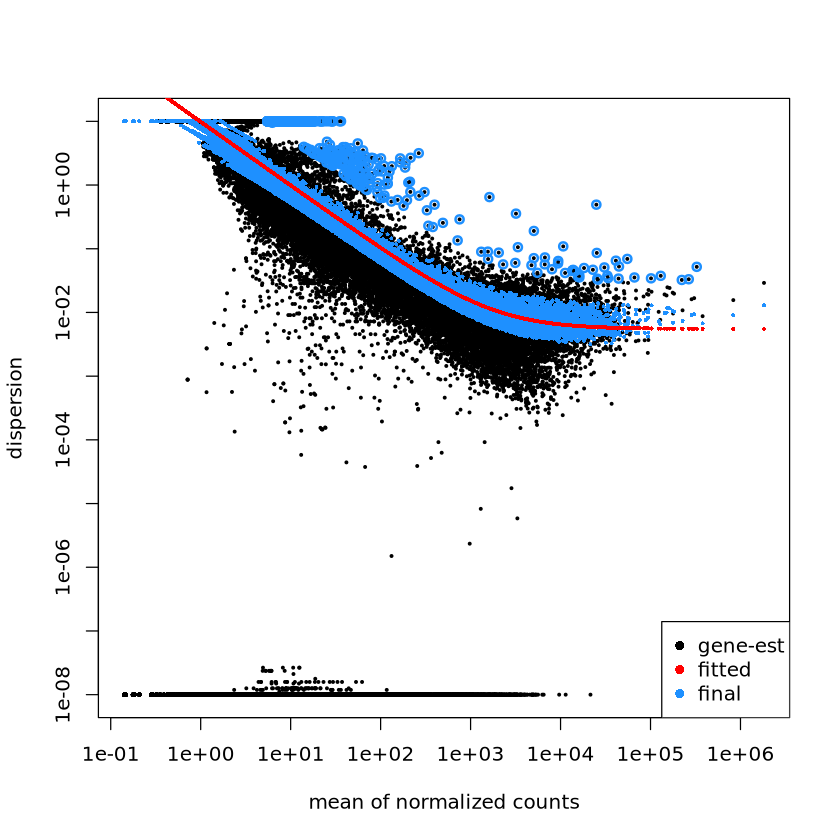

In [22]:
plotDispEsts(dds)

### Transform - VST main

In [23]:
vsd <- vst(dds, blind=FALSE)
head(assay(vsd), 3)

,/usr/users/papantonis1/aman/rnaseq_data/star_results/S55_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S56_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S57_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S58_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S59_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S60_Aligned.sortedByCoord.out.bam
ENSG00000290825.2,8.763552,8.763552,8.763552,8.763552,8.853386,8.763552
ENSG00000223972.6,8.763552,8.763552,8.763552,8.763552,8.763552,8.763552
ENSG00000310526.1,9.192389,9.358516,9.942039,9.888528,9.948701,10.029176


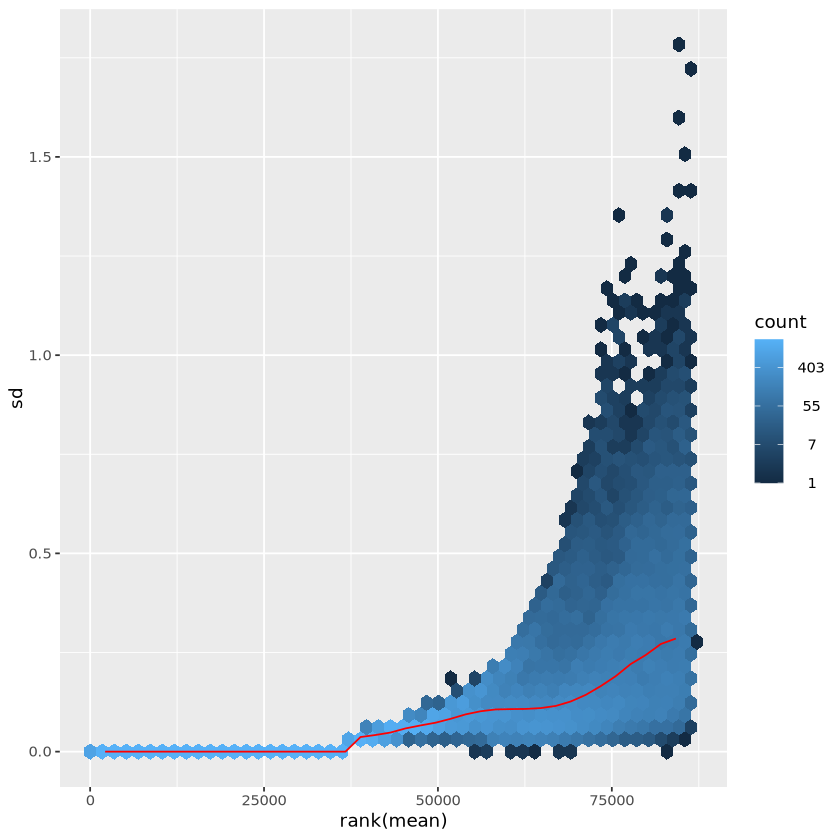

In [24]:
library("vsn")
meanSdPlot(assay(vsd))

### NormTransform

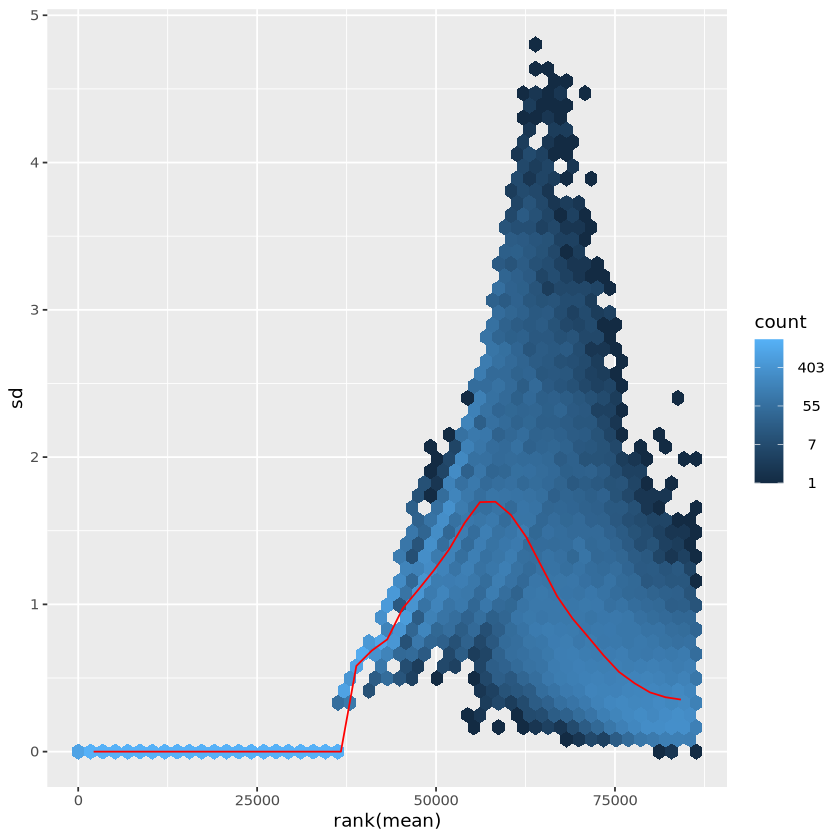

In [25]:
ntd <- normTransform(dds)
meanSdPlot(assay(ntd))

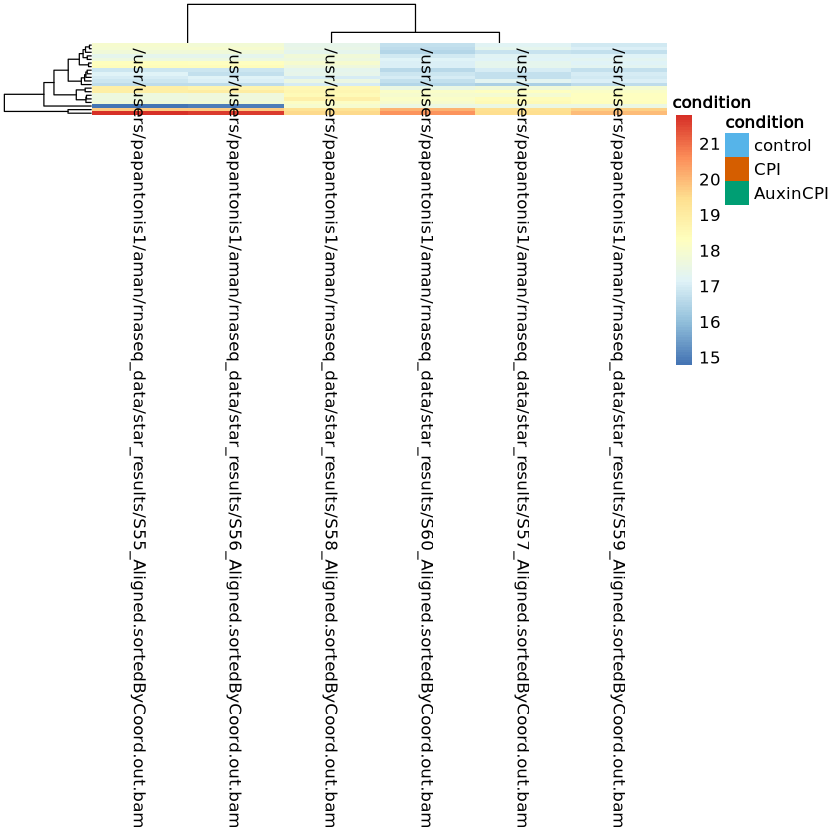

In [26]:
library("pheatmap")

select <- order(rowMeans(counts(dds, normalized=TRUE)), decreasing=TRUE)[1:20]


# Reassign colnames and ensure annotation matches order
colnames(vsd) <- c("S55", "S56", "S57", "S58", "S59", "S60")
df <- as.data.frame(colData(dds)[, "condition", drop = FALSE])
rownames(df) <- colnames(vsd)
df$condition <- factor(df$condition, levels = c("control", "CPI", "AuxinCPI"))



# Define annotation colors
ann_colors <- list(
  condition = c("control" = "#56B4E9", "CPI" = "#D55E00", "AuxinCPI" = "#009E73")
)

pheatmap(
  assay(ntd)[select, ],
  cluster_rows = TRUE,
  show_rownames = FALSE,
  cluster_cols = TRUE,
  annotation_col = df,
  annotation_colors = ann_colors
)


In [27]:
all(colnames(assay(vsd)) == rownames(df))

[1] TRUE

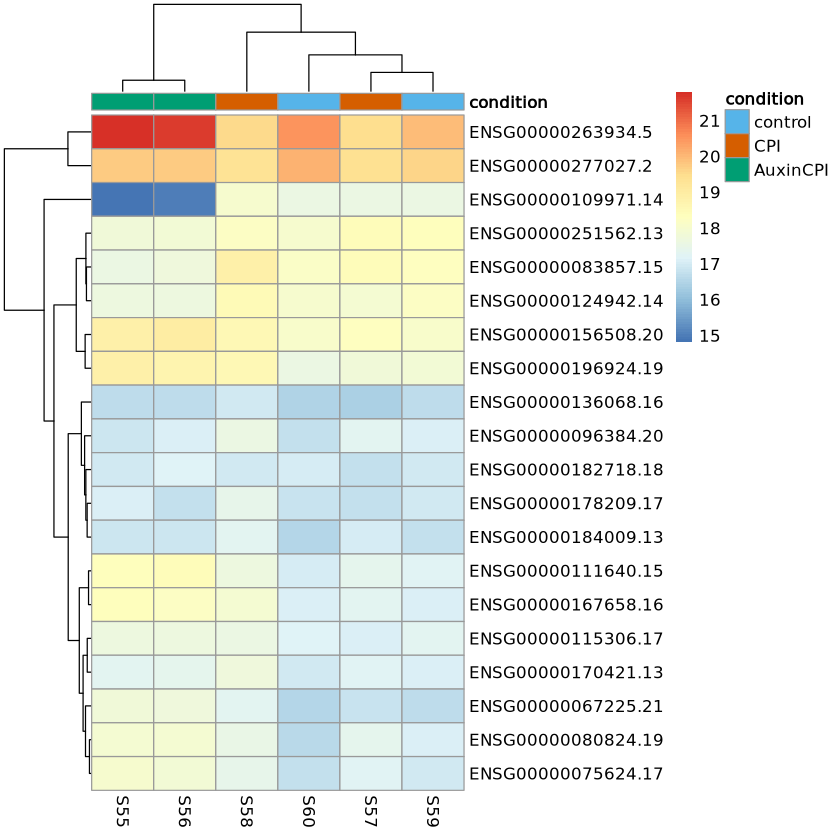

In [69]:
colnames(vsd) <- c("S55", "S56", "S57", "S58", "S59", "S60")
pheatmap(
  assay(vsd)[select, ],
  cluster_rows = TRUE,
  show_rownames = TRUE,
  cluster_cols = TRUE,
  annotation_col = df,
  annotation_colors = ann_colors
)

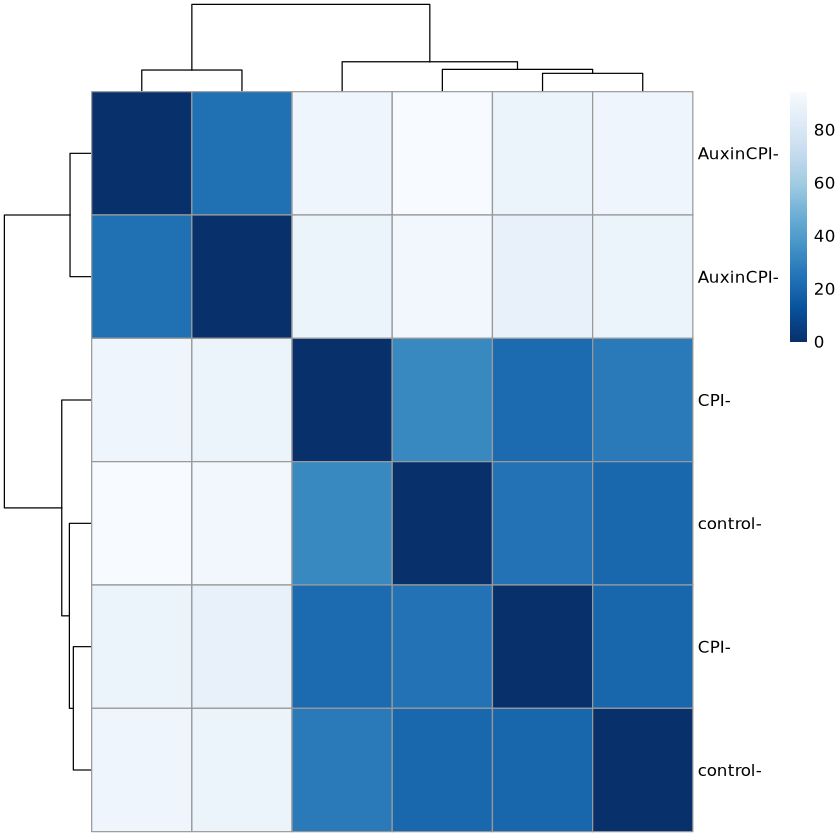

In [29]:
sampleDists <- dist(t(assay(vsd)))
library("RColorBrewer")
sampleDistMatrix <- as.matrix(sampleDists)
rownames(sampleDistMatrix) <- paste(vsd$condition, vsd$type, sep="-")
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows=sampleDists,
         clustering_distance_cols=sampleDists,
         col=colors)

# control and cpi correlated which in a way makes sense biologically

using ntop=500 top features by variance



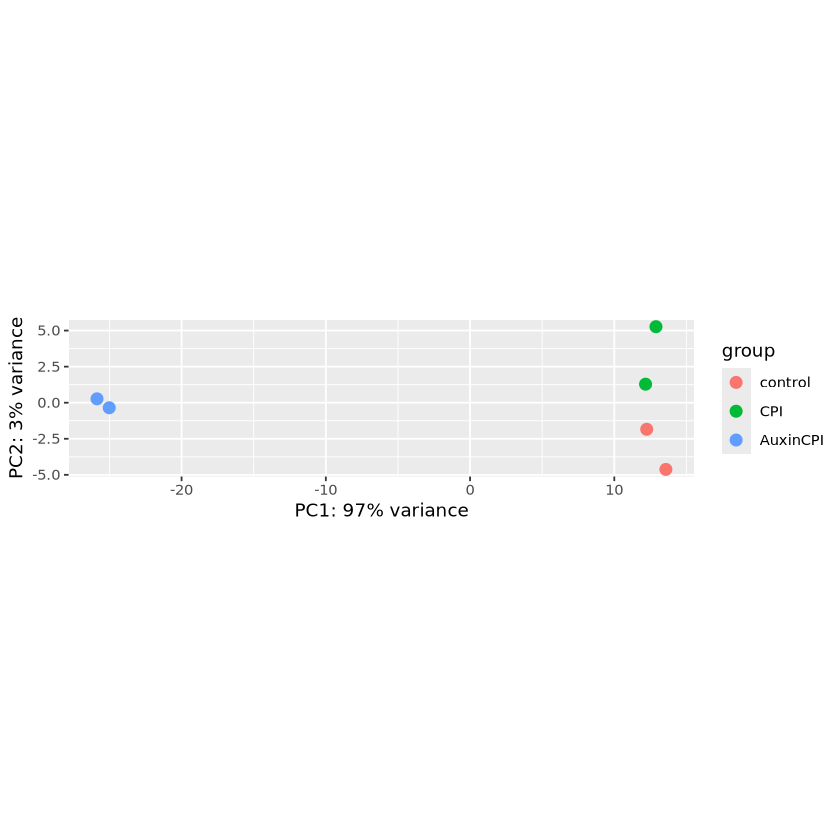

In [30]:
plotPCA(vsd, intgroup=c("condition"))

In [31]:
#options(repr.plot.width = 8, repr.plot.height = 9)
#plotPCA(vsd, intgroup = "condition") + theme(aspect.ratio = 1.5)
pca <- prcomp(t(assay(vsd)))
summary(pca)



Importance of components:
                           PC1      PC2     PC3     PC4     PC5      PC6
Standard deviation     45.4993 10.57308 7.46943 5.94246 5.55822 1.41e-13
Proportion of Variance  0.8985  0.04852 0.02422 0.01533 0.01341 0.00e+00
Cumulative Proportion   0.8985  0.94705 0.97126 0.98659 1.00000 1.00e+00

### Log fold change shrinkage

In [32]:
resultsNames(dds)

[1] "Intercept"                     "condition_CPI_vs_control"     
[3] "condition_AuxinCPI_vs_control"

In [33]:
resLFC <- lfcShrink(dds, coef="condition_CPI_vs_control", type="apeglm")
resLFC

using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895



log2 fold change (MAP): condition CPI vs control 
Wald test p-value: condition CPI vs control 
DataFrame with 86364 rows and 5 columns
                    baseMean log2FoldChange     lfcSE    pvalue      padj
                   <numeric>      <numeric> <numeric> <numeric> <numeric>
ENSG00000290825.2   0.280936    -0.00182447  0.126213  0.621326        NA
ENSG00000223972.6   0.000000             NA        NA        NA        NA
ENSG00000310526.1 227.447545    -0.02542982  0.120621  0.556467  0.806729
ENSG00000227232.6   0.000000             NA        NA        NA        NA
ENSG00000278267.1   0.000000             NA        NA        NA        NA
...                      ...            ...       ...       ...       ...
ENSG00000303867.1          0             NA        NA        NA        NA
ENSG00000303902.1          0             NA        NA        NA        NA
ENSG00000306528.1          0             NA        NA        NA        NA
ENSG00000297844.1          0             NA        

In [34]:
# order based on the pval
resOrdered <- res[order(res$pvalue),]
resOrdered

log2 fold change (MLE): condition CPI vs control 
Wald test p-value: condition CPI vs control 
DataFrame with 86364 rows and 6 columns
                    baseMean log2FoldChange     lfcSE      stat      pvalue
                   <numeric>      <numeric> <numeric> <numeric>   <numeric>
ENSG00000170385.10   8457.71       1.003893  0.114580   8.76151 1.92644e-18
ENSG00000100600.15   4123.34       0.913378  0.140299   6.51021 7.50440e-11
ENSG00000104805.17   3677.86       0.926150  0.145961   6.34520 2.22138e-10
ENSG00000169116.11  10740.23       0.715329  0.113664   6.29336 3.10658e-10
ENSG00000067141.17   2414.47       0.912804  0.152194   5.99763 2.00223e-09
...                      ...            ...       ...       ...         ...
ENSG00000303867.1          0             NA        NA        NA          NA
ENSG00000303902.1          0             NA        NA        NA          NA
ENSG00000306528.1          0             NA        NA        NA          NA
ENSG00000297844.1          0 

In [35]:
# filtering with padj < 0.05
sum(res$padj < 0.05, na.rm=TRUE)

[1] 849

In [36]:
res_raw <- results(dds, contrast = c("condition", "CPI", "control"))

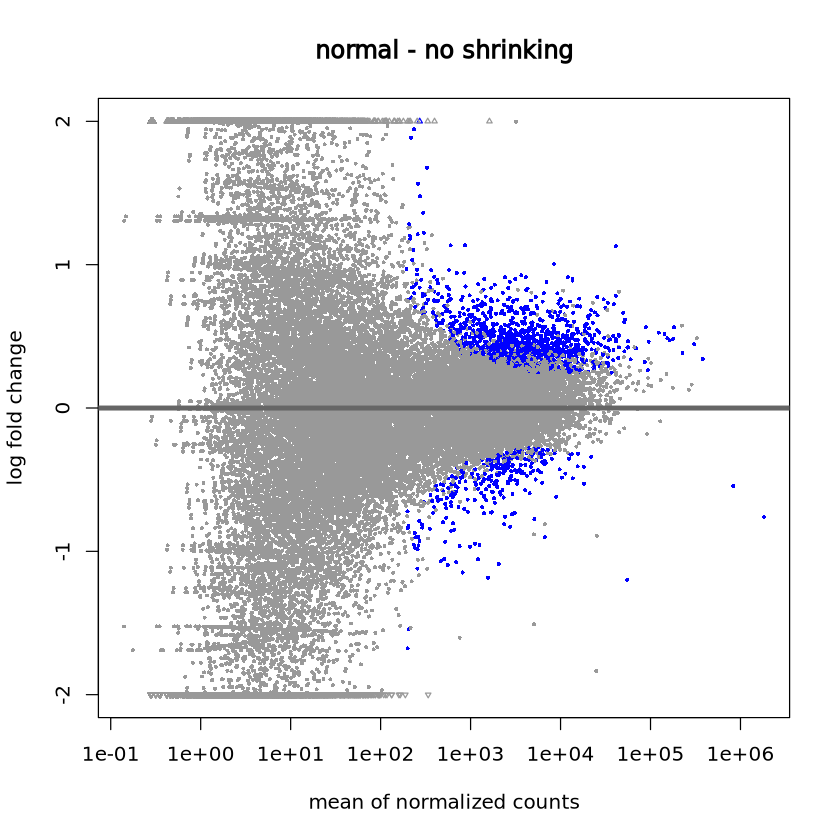

In [37]:
plotMA(res_raw, ylim=c(-2,2), main="normal - no shrinking")

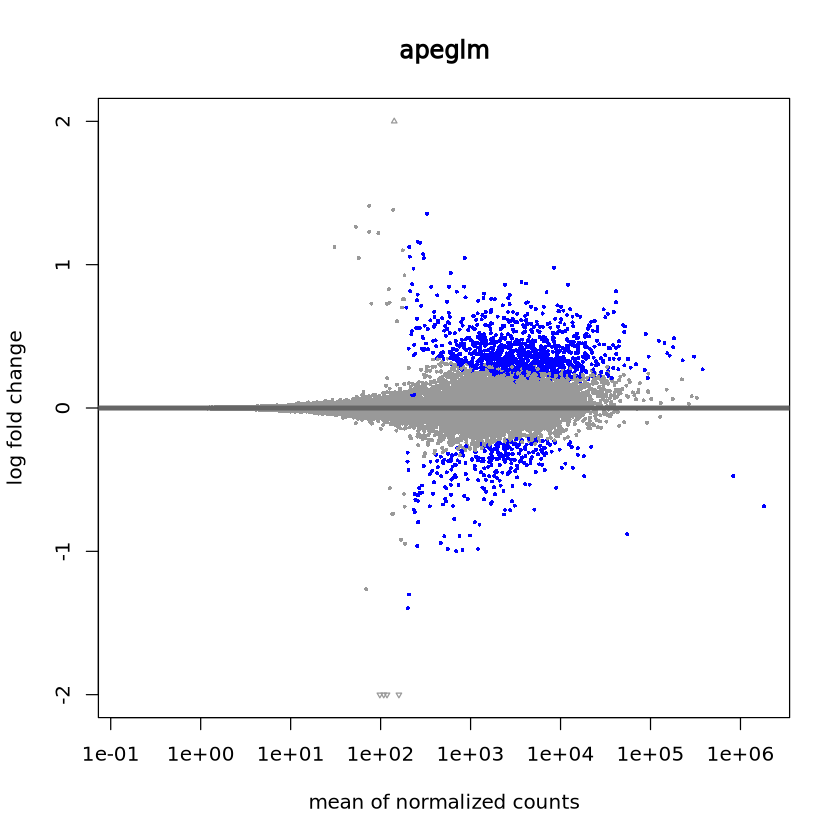

In [38]:
plotMA(resLFC, ylim=c(-2,2), main="apeglm")

In [39]:
mcols(res)$description

[1] "mean of normalized counts for all samples"       
[2] "log2 fold change (MLE): condition CPI vs control"
[3] "standard error: condition CPI vs control"        
[4] "Wald statistic: condition CPI vs control"        
[5] "Wald test p-value: condition CPI vs control"     
[6] "BH adjusted p-values"

In [40]:
sig_res <- res[which(res$padj < 0.05), ]

In [41]:
sig_res

log2 fold change (MLE): condition CPI vs control 
Wald test p-value: condition CPI vs control 
DataFrame with 849 rows and 6 columns
                    baseMean log2FoldChange     lfcSE      stat      pvalue
                   <numeric>      <numeric> <numeric> <numeric>   <numeric>
ENSG00000187961.15   637.683      -0.803631 0.2106553  -3.81491 1.36232e-04
ENSG00000078808.20  5833.847       0.345820 0.1188151   2.91058 3.60763e-03
ENSG00000131584.19  2362.876      -0.809808 0.1619122  -5.00152 5.68792e-07
ENSG00000107404.21  3137.363      -0.504762 0.1277532  -3.95107 7.78017e-05
ENSG00000221978.13 15586.896      -0.318604 0.0864294  -3.68629 2.27550e-04
...                      ...            ...       ...       ...         ...
ENSG00000147383.11   1603.10       0.668064  0.172772   3.86674 1.10301e-04
ENSG00000147394.20   1327.60       0.709374  0.175302   4.04659 5.19695e-05
ENSG00000102030.16   1638.48      -0.361203  0.123731  -2.91925 3.50878e-03
ENSG00000071553.18   5928.33   

In [42]:
upregulated <- sig_res[which(sig_res$log2FoldChange > 0.6), ]
up_genes <- rownames(upregulated)

In [43]:
downregulated <- sig_res[which(sig_res$log2FoldChange < - 0.6), ]
down_genes <- rownames(downregulated)

In [44]:
length(up_genes)

[1] 188

In [45]:
length(down_genes)

[1] 65

In [46]:
setwd("/usr/users/papantonis1/aman/rnaseq_data")

In [47]:
#write.table(up_genes, file="upregulated_genes.txt", quote=FALSE, row.names=FALSE, col.names=FALSE)
#write.table(down_genes, file="downregulated_genes.txt", quote=FALSE, row.names=FALSE, col.names=FALSE)

In [48]:
up_df <- data.frame(
  ensembl = rownames(upregulated),
  log2FC = upregulated$log2FoldChange
)

write.table(up_df, file = "upregulated_genes.txt", sep = "\t", quote = FALSE, row.names = FALSE)

In [49]:
down_df <- data.frame(
  ensembl = rownames(downregulated),
  log2FC = downregulated$log2FoldChange
)
write.table(down_df, file = "downregulated_genes.txt", sep = "\t", quote = FALSE, row.names = FALSE)

In [50]:
# Full result from DESeq2, no filtering by padj
gene_df <- data.frame(
  ensembl = rownames(res),
  log2FC = res$log2FoldChange
)

# Optional: remove NA
gene_df <- na.omit(gene_df)

# Write full ranked gene list for GSEA
write.table(gene_df, file = "ranked_gene_list.txt", sep = "\t", quote = FALSE, row.names = FALSE)

gene_df

,ensembl,log2FC
,<chr>,<dbl>
1,ENSG00000290825.2,-2.42258691
3,ENSG00000310526.1,-0.18916477
6,ENSG00000243485.6,-1.25585264
9,ENSG00000308361.1,0.00000000
14,ENSG00000241860.8,-0.16632248
18,ENSG00000308579.1,-1.95519125
20,ENSG00000269981.1,1.30369400
23,ENSG00000222623.1,-1.68987839
26,ENSG00000310527.1,-0.39200970


In [51]:
summary(gene_df)

   ensembl              log2FC         
 Length:49321       Min.   :-6.452813  
 Class :character   1st Qu.:-0.239804  
 Mode  :character   Median : 0.000000  
                    Mean   :-0.004435  
                    3rd Qu.: 0.247107  
                    Max.   : 6.559015  

In [52]:
up_df

ensembl,log2FC
<chr>,<dbl>
ENSG00000171603.18,0.6236341
ENSG00000083444.17,0.6531234
ENSG00000117298.16,0.7427075
ENSG00000133216.17,0.8813826
ENSG00000090020.11,0.7566302
ENSG00000204138.13,0.6088367
ENSG00000134690.11,0.6600042
ENSG00000117399.14,0.7998670
ENSG00000142949.18,0.7740623


In [53]:
down_df

ensembl,log2FC
<chr>,<dbl>
ENSG00000187961.15,-0.8036312
ENSG00000131584.19,-0.8098075
ENSG00000197530.13,-0.6306522
ENSG00000158286.13,-0.7327465
ENSG00000142733.18,-0.7232720
ENSG00000200087.1,-1.1987023
ENSG00000274210.1,-0.9842403
ENSG00000143630.10,-0.9750524
ENSG00000307581.1,-1.6777565


Loading required package: ggplot2

Loading required package: ggrepel



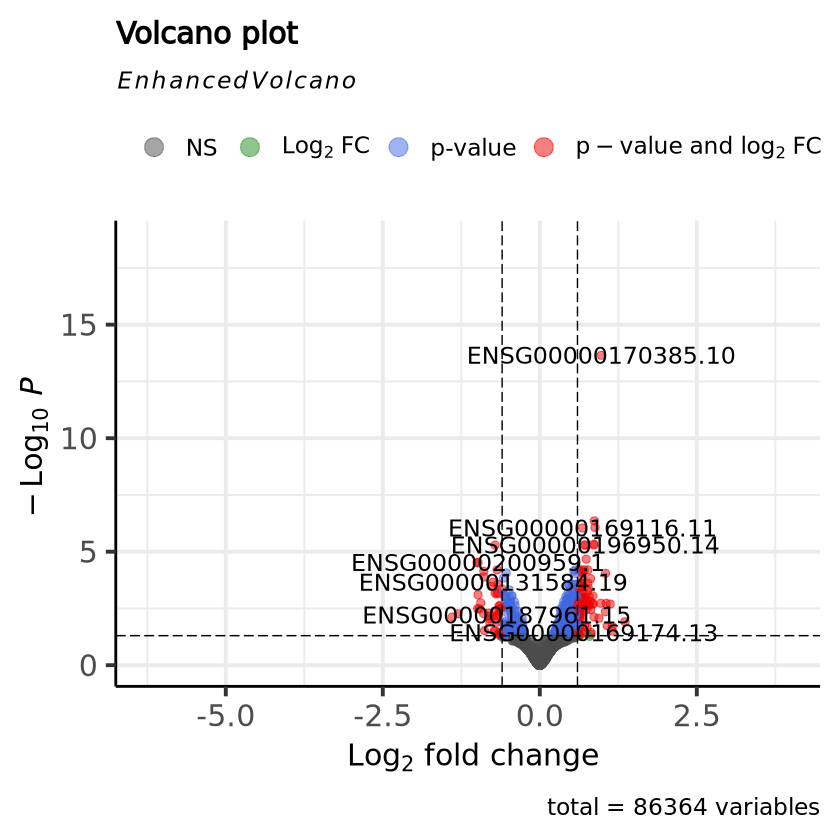

In [54]:
library(EnhancedVolcano)
EnhancedVolcano(resLFC,
  lab = rownames(resLFC),
  x = 'log2FoldChange',
  y = 'padj',
  pCutoff = 0.05,
  FCcutoff = 0.6)

# resLFC used as it is the shrunk one

### The next step is to display the gene names instead of the ensembl ids

In [55]:
# todo

In [56]:
# Skip 'version="devel"' which pulls the latest (3.22, needs R 4.5)
#BiocManager::install(version = "3.18")
#BiocManager::install("biomaRt")


In [57]:
library(biomaRt)

In [58]:
# Set up biomart
mart <- useEnsembl(biomart = "genes", dataset = "hsapiens_gene_ensembl")

# Remove version suffix (.10, .11 etc.)
ids <- gsub("\\..*", "", rownames(resLFC))

# Query gene names
annot <- getBM(
  attributes = c("ensembl_gene_id", "hgnc_symbol"),
  filters = "ensembl_gene_id",
  values = ids,
  mart = mart
)

In [59]:
annot

ensembl_gene_id,hgnc_symbol
<chr>,<chr>
ENSG00000000938,FGR
ENSG00000001460,STPG1
ENSG00000001461,NIPAL3
ENSG00000004455,AK2
ENSG00000004487,KDM1A
ENSG00000006555,TTC22
ENSG00000007341,ST7L
ENSG00000007923,DNAJC11
ENSG00000007968,E2F2


In [60]:
# Merge with result table
resLFC$ensembl_id <- gsub("\\..*", "", rownames(resLFC))
res_annot <- merge(as.data.frame(resLFC), annot, by.x = "ensembl_id", by.y = "ensembl_gene_id", all.x = TRUE)

# Set gene symbols as rownames (fallback to Ensembl if missing)
res_annot$label <- ifelse(res_annot$hgnc_symbol == "", res_annot$ensembl_id, res_annot$hgnc_symbol)

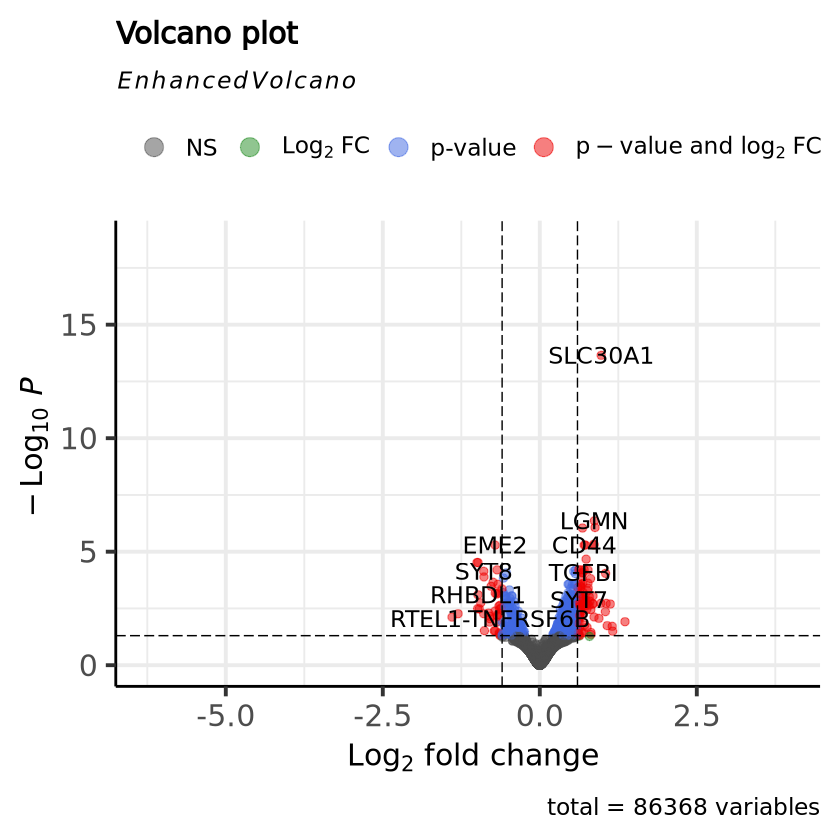

In [61]:
EnhancedVolcano(
  res_annot,
  lab = res_annot$label,
  x = 'log2FoldChange',
  y = 'padj',
  pCutoff = 0.05,
  FCcutoff = 0.6
)


In [62]:
head(up_df)

,ensembl,log2FC
,<chr>,<dbl>
1,ENSG00000171603.18,0.6236341
2,ENSG00000083444.17,0.6531234
3,ENSG00000117298.16,0.7427075
4,ENSG00000133216.17,0.8813826
5,ENSG00000090020.11,0.7566302
6,ENSG00000204138.13,0.6088367


In [63]:
head(down_df)

,ensembl,log2FC
,<chr>,<dbl>
1,ENSG00000187961.15,-0.8036312
2,ENSG00000131584.19,-0.8098075
3,ENSG00000197530.13,-0.6306522
4,ENSG00000158286.13,-0.7327465
5,ENSG00000142733.18,-0.7232720
6,ENSG00000200087.1,-1.1987023


In [64]:
# Load biomaRt
library(biomaRt)

# Strip version suffixes
up_df$ensembl_id <- sub("\\..*", "", up_df$ensembl)
down_df$ensembl_id <- sub("\\..*", "", down_df$ensembl)

# Connect to Ensembl
mart <- useEnsembl(biomart = "genes", dataset = "hsapiens_gene_ensembl")

# Get gene symbols
gene_info <- getBM(
  attributes = c("ensembl_gene_id", "hgnc_symbol"),
  filters = "ensembl_gene_id",
  values = unique(c(up_df$ensembl_id, down_df$ensembl_id)),
  mart = mart
)

# Merge gene symbols with up_df
up_df_annot <- merge(up_df, gene_info, by.x = "ensembl_id", by.y = "ensembl_gene_id", all.x = TRUE)

# Merge gene symbols with down_df
down_df_annot <- merge(down_df, gene_info, by.x = "ensembl_id", by.y = "ensembl_gene_id", all.x = TRUE)

In [65]:
# Replace missing hgnc_symbol with ensembl_id
up_df_annot$hgnc_symbol <- ifelse(
  up_df_annot$hgnc_symbol == "" | is.na(up_df_annot$hgnc_symbol),
  up_df_annot$ensembl_id,
  up_df_annot$hgnc_symbol
)

down_df_annot$hgnc_symbol <- ifelse(
  down_df_annot$hgnc_symbol == "" | is.na(down_df_annot$hgnc_symbol),
  down_df_annot$ensembl_id,
  down_df_annot$hgnc_symbol
)


In [66]:
up_df_annot

ensembl_id,ensembl,log2FC,hgnc_symbol
<chr>,<chr>,<dbl>,<chr>
ENSG00000005339,ENSG00000005339.15,0.6531038,CREBBP
ENSG00000011347,ENSG00000011347.10,0.6965520,SYT7
ENSG00000013288,ENSG00000013288.9,0.7036436,MAN2B2
ENSG00000026508,ENSG00000026508.21,0.7497931,CD44
ENSG00000030582,ENSG00000030582.19,0.9126872,GRN
ENSG00000041982,ENSG00000041982.17,0.6878423,TNC
ENSG00000044574,ENSG00000044574.9,1.1297088,HSPA5
ENSG00000047662,ENSG00000047662.5,1.3618516,FAM184B
ENSG00000049323,ENSG00000049323.16,0.6825615,LTBP1


In [67]:
down_df_annot

ensembl_id,ensembl,log2FC,hgnc_symbol
<chr>,<chr>,<dbl>,<chr>
ENSG00000026036,ENSG00000026036.23,-0.9577087,RTEL1-TNFRSF6B
ENSG00000101246,ENSG00000101246.20,-0.6434456,ARFRP1
ENSG00000103269,ENSG00000103269.14,-1.0960115,RHBDL1
ENSG00000105173,ENSG00000105173.14,-0.8496167,CCNE1
ENSG00000108465,ENSG00000108465.15,-0.6394644,CDK5RAP3
ENSG00000108960,ENSG00000108960.9,-0.6200365,MMD
ENSG00000111554,ENSG00000111554.15,-0.6692859,MDM1
ENSG00000118513,ENSG00000118513.21,-0.8976397,MYB
ENSG00000122870,ENSG00000122870.12,-0.9024617,BICC1


In [68]:
write.table(up_df_annot, file = "upregulated_genes_deseq.txt", sep = "\t", quote = FALSE, row.names = FALSE)
write.table(down_df_annot, file = "downregulated_genes_deseq.txt", sep = "\t", quote = FALSE, row.names = FALSE)